In [338]:
import pandas as pd
import re
import statistics as st
from scipy import stats # библиотека для расчетов
import plotly.express as px
import matplotlib.pyplot as plt # библиотека визуализации
from sklearn.metrics import matthews_corrcoef
import category_encoders as ce
from sklearn import preprocessing
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('wine_cleared.csv')
#display(df.info())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             129971 non-null  int64  
 1   country                129908 non-null  object 
 2   description            129971 non-null  object 
 3   designation            129971 non-null  object 
 4   points                 129971 non-null  int64  
 5   price                  129971 non-null  float64
 6   province               129908 non-null  object 
 7   region_1               129971 non-null  object 
 8   taster_name            129971 non-null  object 
 9   taster_twitter_handle  129971 non-null  object 
 10  title                  129971 non-null  object 
 11  variety                129970 non-null  object 
 12  winery                 129971 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 12.9+ MB


In [339]:
df['price_round'] = df['price'].round().astype(int)
regex = '\d{4}' # регулярное выражение для нахождения чисел
df['year'] = df['title'].str.findall(regex).str.get(0)
df['year']=df['year'].astype(float)
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,taster_name,taster_twitter_handle,title,variety,winery,price_round,year
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,35.363389,Sicily & Sardinia,Etna,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,35,2013.0
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.000000,Douro,unknown,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,15,2011.0
2,2,US,"Tart and snappy, the flavors of lime flesh and...",unknown,87,14.000000,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,14,2013.0
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.000000,Michigan,Lake Michigan Shore,Alexander Peartree,unknown,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,13,2013.0
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.000000,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,65,2012.0


In [340]:
df['is_usa'] = df['country'].apply(lambda x: 1 if x == 'US' else 0)
df['is_france'] = df['country'].apply(lambda x: 1 if x == 'France' else 0)
df['is_italy'] = df['country'].apply(lambda x: 1 if x == 'Italy' else 0)
df['old_wine']=df['year'].apply(lambda x: 1 if x<2010 else 0)
df['locality']=df['title'].str.findall(r'\((.*?)\)') #(?<=\()\w*
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,taster_name,taster_twitter_handle,title,variety,winery,price_round,year,is_usa,is_france,is_italy,old_wine,locality
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,35.363389,Sicily & Sardinia,Etna,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,35,2013.0,0,0,1,0,[Etna]
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.000000,Douro,unknown,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,15,2011.0,0,0,0,0,[Douro]
2,2,US,"Tart and snappy, the flavors of lime flesh and...",unknown,87,14.000000,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,14,2013.0,1,0,0,0,[Willamette Valley]
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.000000,Michigan,Lake Michigan Shore,Alexander Peartree,unknown,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,13,2013.0,1,0,0,0,[Lake Michigan Shore]
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.000000,Oregon,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,65,2012.0,1,0,0,0,[Willamette Valley]


In [341]:
country_population = pd.read_csv('country_population.csv', sep=';')

country_population[country_population['country'] == 'Italy']

,country,population
24,Italy,"59,097,904"


In [342]:
df=df.join(country_population.set_index('country'), on='country')

In [343]:
country_area = pd.read_csv('country_area.csv', sep=';')
country_area

,country,area
0,Russia,17075400.00
1,Canada,9984670.00
2,China,9596960.00
3,US,9372610.00
4,Brazil,8547000.00
...,...,...
188,San Marino,61.00
189,Tuvalu,26.00
190,Nauru,21.00
191,Monaco,2.00


In [344]:
df=df.join(country_area.set_index('country'), on='country')
df=df.drop(labels='Unnamed: 0', axis=1)
df=df.rename(columns={'area':'area_country'})

In [345]:
df[df['title']=='Gård 2014 Grand Klasse Reserve Lawrence Vineyards Viognier (Columbia Valley (WA))']['area_country']

94    9372610.0
Name: area_country, dtype: float64

In [346]:
df['year'] = pd.to_datetime(df['year'], errors='coerce', format='%Y')
df['years_dif']=df['year'].apply(lambda x: (pd.to_datetime('2022-1-12')-x) if x != pd.NaT else x)
df['years_dif'].describe()

count                          125332
mean     4207 days 21:48:01.217885312
std      2275 days 15:12:36.496162080
min                1837 days 00:00:00
25%                3298 days 00:00:00
50%                4029 days 00:00:00
75%                4759 days 00:00:00
max               98627 days 00:00:00
Name: years_dif, dtype: object

In [347]:
"""df['year']=df['year'].astype('category')
ord_encoder = ce.OrdinalEncoder()
data_bin = ord_encoder.fit_transform(df[['year']])
df_encoded = pd.concat([df, data_bin], axis=1)
df_encoded.shape"""

"df['year']=df['year'].astype('category')\nord_encoder = ce.OrdinalEncoder()\ndata_bin = ord_encoder.fit_transform(df[['year']])\ndf_encoded = pd.concat([df, data_bin], axis=1)\ndf_encoded.shape"

In [348]:
"""encoder = ce.OneHotEncoder(cols=['taster_name'], use_cat_names=True) # указываем столбец для кодирования
type_bin = encoder.fit_transform(df_encoded['taster_name'])
df_encoded_2 = pd.concat([df_encoded, type_bin], axis=1)
df_encoded_2.shape"""

"encoder = ce.OneHotEncoder(cols=['taster_name'], use_cat_names=True) # указываем столбец для кодирования\ntype_bin = encoder.fit_transform(df_encoded['taster_name'])\ndf_encoded_2 = pd.concat([df_encoded, type_bin], axis=1)\ndf_encoded_2.shape"

In [349]:
"""df_for_enc=pd.read_csv('wine_cleared.csv')
bin_encoder = ce.BinaryEncoder(cols=['taster_twitter_handle']) # указываем столбец для кодирования
type_bin = bin_encoder.fit_transform(df_for_enc['taster_twitter_handle'])
df_enc = pd.concat([df_for_enc, type_bin], axis=1)"""


"df_for_enc=pd.read_csv('wine_cleared.csv')\nbin_encoder = ce.BinaryEncoder(cols=['taster_twitter_handle']) # указываем столбец для кодирования\ntype_bin = bin_encoder.fit_transform(df_for_enc['taster_twitter_handle'])\ndf_enc = pd.concat([df_for_enc, type_bin], axis=1)"

In [350]:
"""bin_encoder = ce.BinaryEncoder(cols=['taster_twitter_handle']) # указываем столбец для кодирования
type_bin = bin_encoder.fit_transform(df_for_enc['taster_twitter_handle'])
df_enc = pd.concat([df_for_enc, type_bin], axis=1)"""


"bin_encoder = ce.BinaryEncoder(cols=['taster_twitter_handle']) # указываем столбец для кодирования\ntype_bin = bin_encoder.fit_transform(df_for_enc['taster_twitter_handle'])\ndf_enc = pd.concat([df_for_enc, type_bin], axis=1)"

In [351]:
"""r_scaler = preprocessing.RobustScaler()

df=pd.read_csv('wine_cleared.csv')
#df=df.drop(labels='Unnamed: 0',axis=1)
# кодируем исходный датасет
df_r=pd.DataFrame(df['price'])
col_names = list(df_r.columns)
df_r = r_scaler.fit_transform(df_r)
df_r = pd.DataFrame(df_r, columns=col_names)
fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('Распределения после RobustScaler')

sns.kdeplot(df_r['price'], ax=ax1)
df_r['price'].sum()"""

"r_scaler = preprocessing.RobustScaler()\n\ndf=pd.read_csv('wine_cleared.csv')\n#df=df.drop(labels='Unnamed: 0',axis=1)\n# кодируем исходный датасет\ndf_r=pd.DataFrame(df['price'])\ncol_names = list(df_r.columns)\ndf_r = r_scaler.fit_transform(df_r)\ndf_r = pd.DataFrame(df_r, columns=col_names)\nfig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))\nax1.set_title('Распределения после RobustScaler')\n\nsns.kdeplot(df_r['price'], ax=ax1)\ndf_r['price'].sum()"

In [352]:

"""# инициализируем стандартизатор StandardScaler
s_scaler = preprocessing.StandardScaler()

df=pd.read_csv('wine_cleared.csv')
#df=df.drop(labels='Unnamed: 0',axis=1)
# кодируем исходный датасет
df_r=pd.DataFrame(df['price'])
col_names = list(df_r.columns)
# кодируем исходный датасет
df_s = s_scaler.fit_transform(df_r)

# Преобразуем промежуточный датасет в полноценный датафрейм для визуализации
df_s = pd.DataFrame(df_s, columns=col_names)

fig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))
ax1.set_title('Распределения после StandardScaler')

sns.kdeplot(df_s['price'], ax=ax1)
df_s['price'][129968].round(2)"""

"# инициализируем стандартизатор StandardScaler\ns_scaler = preprocessing.StandardScaler()\n\ndf=pd.read_csv('wine_cleared.csv')\n#df=df.drop(labels='Unnamed: 0',axis=1)\n# кодируем исходный датасет\ndf_r=pd.DataFrame(df['price'])\ncol_names = list(df_r.columns)\n# кодируем исходный датасет\ndf_s = s_scaler.fit_transform(df_r)\n\n# Преобразуем промежуточный датасет в полноценный датафрейм для визуализации\ndf_s = pd.DataFrame(df_s, columns=col_names)\n\nfig, (ax1) = plt.subplots(ncols=1, figsize=(10, 8))\nax1.set_title('Распределения после StandardScaler')\n\nsns.kdeplot(df_s['price'], ax=ax1)\ndf_s['price'][129968].round(2)"

C:\Users\lepni\AppData\Local\Temp\ipykernel_1480\2753167298.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(), annot=True) # включаем отображение коэффициентов


<AxesSubplot: >

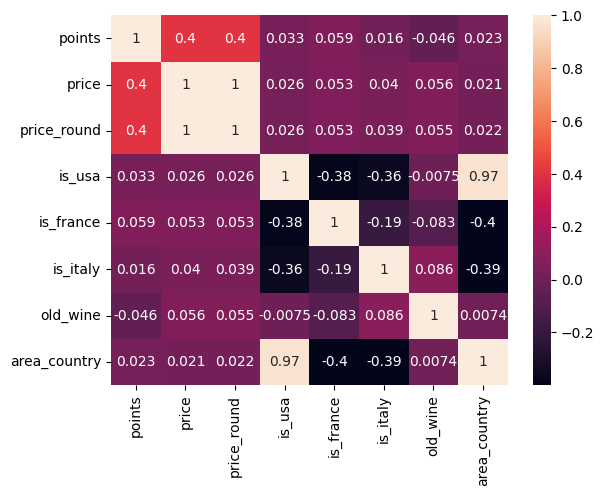

In [354]:
sns.heatmap(df.corr(), annot=True) # включаем отображение коэффициентов